**Overview**  
This notebook describes folloiwing stages:
1. Creating functions to:
    - perform search for optimal algorithm parameters;
    - train model;
    - calculate the most important metrics;
    - plot parity plots 
2. Assess the results of following algorithms:
    - Logistic regression;
    - Random Forest;
    - Gradient Boosting as implemented in LightBoost;
    - Support Vector Machines;
    - K-Nearest Neighborrs
3. Create dataframe with the main indiators of models' performance

All models are trained with PaDEL descriptors


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsRegressor

First, let's import datasets and y-target, created earlier:

In [2]:
with open ('Features_PaDEL/padel_descks.pickle', 'rb') as inp:
    padel_descs = pickle.load(inp)

In [3]:
data_anionic = pd.read_csv('Data/Data_anionic.csv')
target_anionic = data_anionic['Cc ']

data_cationic = pd.read_csv('Data/Data_cationic.csv')
target_cationic = data_cationic['Cc ']

data_extended = pd.read_csv('Data/Data_extended.csv')
target_extended = data_extended['Cc ']

data_non_ionic = pd.read_csv('Data/Data_non_ionic.csv')
target_non_ionic = data_non_ionic['Cc ']

targets = {'PaDEL_anionic': target_anionic, 'PaDEL_non_ionic': target_non_ionic, 'PaDEL_extended':target_extended, 'PaDEL_cationic': target_cationic}

In [4]:
scores_anionic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_cationic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_non_ionic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_extended = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores = {'PaDEL_anionic': scores_anionic, 'PaDEL_cationic':scores_cationic, 'PaDEL_non_ionic': scores_non_ionic, 'PaDEL_extended':scores_extended}

Subfunction below is to retrieve best model from Trials object ans is used in main functions

In [5]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']

This function makes all the calculations and plotting and saves the results into *Score* dictionary

In [6]:
def calculate_to_score(estimator, estimator_name, param_grid, descriptors_dict = padel_descs, targets = targets, n_iters = 30):
    fig, axes = plt.subplots(1, 4, figsize = (12,8))
    i = 0
    #Iterate through key items - names of classes of surfactants
    for key, value in descriptors_dict.items():
        target = targets[key]
        X_train, X_test, y_train, y_test = train_test_split(value, target, random_state = 0)
        #Objective fuction is what we optimize.  We optimize mean absolute error
        def objective(params, X, target):
            pipe = make_pipeline(StandardScaler(), estimator)
            pipe.set_params(**params)
            y_cv_pred = cross_val_predict(pipe, X, target, cv=10)
            cv_rmse = np.sqrt(root_mean_squared_error(target, y_cv_pred))
            cv_r2 = r2_score(target, y_cv_pred)
            
            score = cross_val_score(pipe, X, target, cv = 10, scoring = 'neg_mean_absolute_error')
            return {'loss':-score.mean(), 'status':STATUS_OK, 'Trained_model':pipe, 'rmse':cv_rmse, 'r2':cv_r2}
        
        trials = Trials()
        best = fmin(partial(objective, X = X_train, target = y_train), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  n_iters)
        print(best)
        #Get best trained model
        best_estimator  = get_best_model_from_trials(trials)['Trained_model']
      
        #Get the results of the best 5-fold cross-validation
        cv_r2 = get_best_model_from_trials(trials)['r2']
        cv_rmse = get_best_model_from_trials(trials)['rmse']
        cv_mae = get_best_model_from_trials(trials)['loss']

        #Add the CV result into scores dictionary
        scores[key]['Descriptors'].append('PaDEL')
        scores[key]['R2_cv'].append(cv_r2)
        scores[key]['RMSE_cv'].append(cv_rmse)
        scores[key]['MAE_cv'].append(cv_mae)

        #fit best estimator on train set and add into scores dictionary
        best_estimator.fit(X_train, y_train)
        predictions = best_estimator.predict(X_test)
        predictions_train = best_estimator.predict(X_train)
        scores[key]['Estimator'].append(estimator_name)
        scores[key]['R2_test'].append(r2_score(y_test, predictions))
        scores[key]['R2_train'].append(r2_score(y_train, predictions_train))
        
        scores[key]['RMSE_test'].append(root_mean_squared_error(y_test, predictions))
        scores[key]['RMSE_train'].append(root_mean_squared_error(y_train, predictions_train))

        
        scores[key]['MAE_test'].append(mean_absolute_error(y_test, predictions))
        scores[key]['MAE_train'].append(mean_absolute_error(y_train, predictions_train))
        #Make parity plot
        axes[i].plot(y_test, predictions, 'ro', label = 'Test values')
        axes[i].plot(y_train, predictions_train, 'go', label = 'Train values')
        axes[i].plot([target.min(),target.max()], [target.min(),target.max()])
        axes[i].set_title('{}'.format(key))
        axes[i].set_xlabel('True test values')
        axes[i].set_ylabel('Predicted test values')
        axes[i].legend()
        i += 1
    plt.tight_layout()
    plt.savefig('PaDEL_{}_scattter.png'.format(estimator_name))
    plt.tight_layout()

Let's test the function with Ridge regression

100%|██████████| 30/30 [00:09<00:00,  3.10trial/s, best loss: 0.9292063903981183]
{'alpha': 69.95332303268256, 'solver': 6}
100%|██████████| 30/30 [00:26<00:00,  1.15trial/s, best loss: 1.8494241807452922]
{'alpha': 7.146697730169918, 'solver': 6}
100%|██████████| 30/30 [01:07<00:00,  2.26s/trial, best loss: 1.585913131762833] 
{'alpha': 22.030924265967798, 'solver': 2}
100%|██████████| 30/30 [00:10<00:00,  2.96trial/s, best loss: 0.6174760442477334]
{'alpha': 18.3243813665098, 'solver': 6}


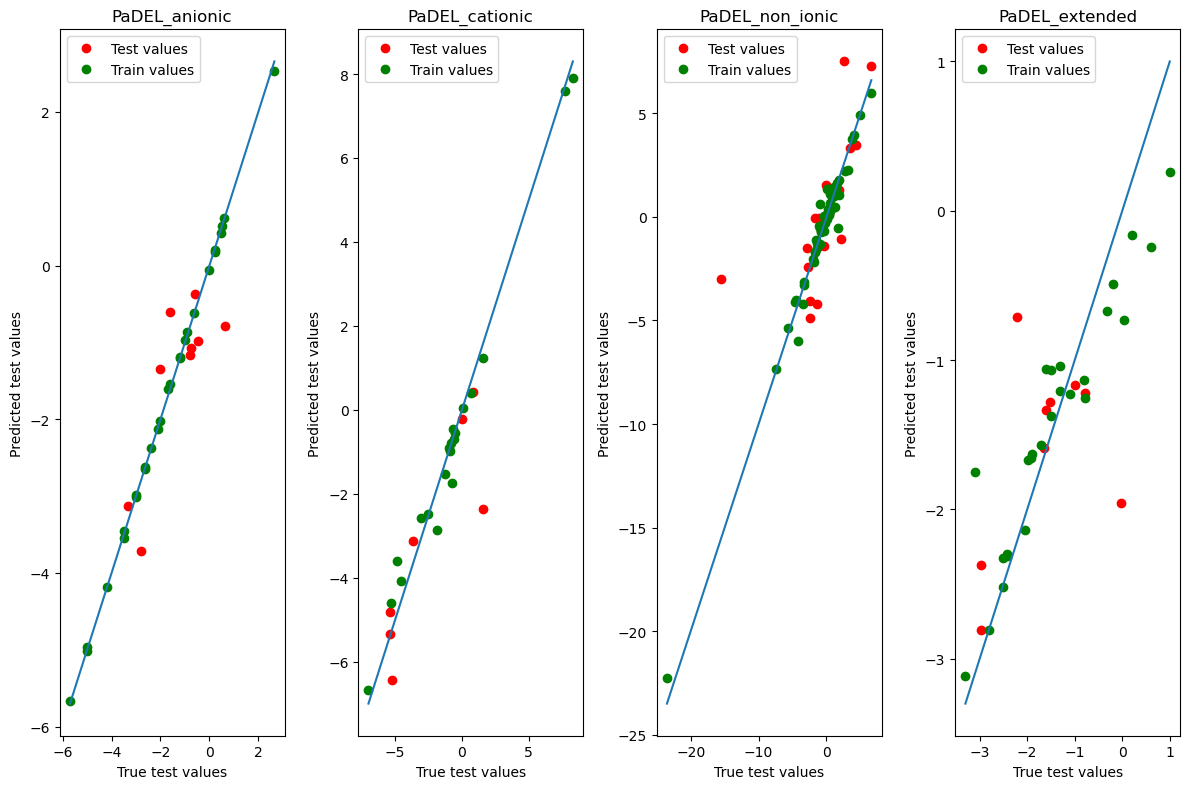

In [11]:
calculate_to_score(Ridge(max_iter = 10000), estimator_name='Linear Regression', 
                   param_grid = {'ridge__alpha':hp.loguniform(label = 'alpha', low = -4*np.log(10), high  = 2*np.log(10)),
                                'ridge__solver':hp.choice(label = 'solver', options = ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg','sag', 'saga'])})

Let's continue with other models. The first one will be
**Random Forest Regression**

In [12]:
space = {
    'randomforestregressor__max_depth': hp.randint('max_depth', 3, 15),  
    'randomforestregressor__max_features': hp.choice('max_features', [0.3, 0.5, 'sqrt', 'log2']), 
    'randomforestregressor__min_samples_split': hp.randint('min_samples_split', 5, 20),  
    'randomforestregressor__min_samples_leaf': hp.randint('min_samples_leaf', 3, 10), 
    'randomforestregressor__criterion': hp.choice('criterion', ["squared_error", "absolute_error"]), 
    'randomforestregressor__ccp_alpha': hp.uniform('ccp_alpha', 0, 0.1),  
    'randomforestregressor__n_estimators': hp.randint('n_estimators', 50, 200),  
    'randomforestregressor__bootstrap': hp.choice('bootstrap', [True]),  
    'randomforestregressor__max_samples': hp.uniform('max_samples', 0.6, 0.95)} 

100%|██████████| 30/30 [01:13<00:00,  2.46s/trial, best loss: 1.24965481411863]  
{'bootstrap': 0, 'ccp_alpha': 0.054655134415887534, 'criterion': 1, 'max_depth': 11, 'max_features': 0, 'max_samples': 0.8602800163636183, 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 171}
100%|██████████| 30/30 [01:17<00:00,  2.58s/trial, best loss: 2.4403600182149363]
{'bootstrap': 0, 'ccp_alpha': 0.0836151267005856, 'criterion': 1, 'max_depth': 12, 'max_features': 1, 'max_samples': 0.8626697317395904, 'min_samples_leaf': 3, 'min_samples_split': 18, 'n_estimators': 183}
100%|██████████| 30/30 [01:12<00:00,  2.42s/trial, best loss: 1.4254042417212116]
{'bootstrap': 0, 'ccp_alpha': 0.0001344201296054684, 'criterion': 0, 'max_depth': 10, 'max_features': 2, 'max_samples': 0.8351797241822612, 'min_samples_leaf': 6, 'min_samples_split': 6, 'n_estimators': 109}
100%|██████████| 30/30 [01:09<00:00,  2.33s/trial, best loss: 0.757586129283489] 
{'bootstrap': 0, 'ccp_alpha': 0.08876582783451682, 

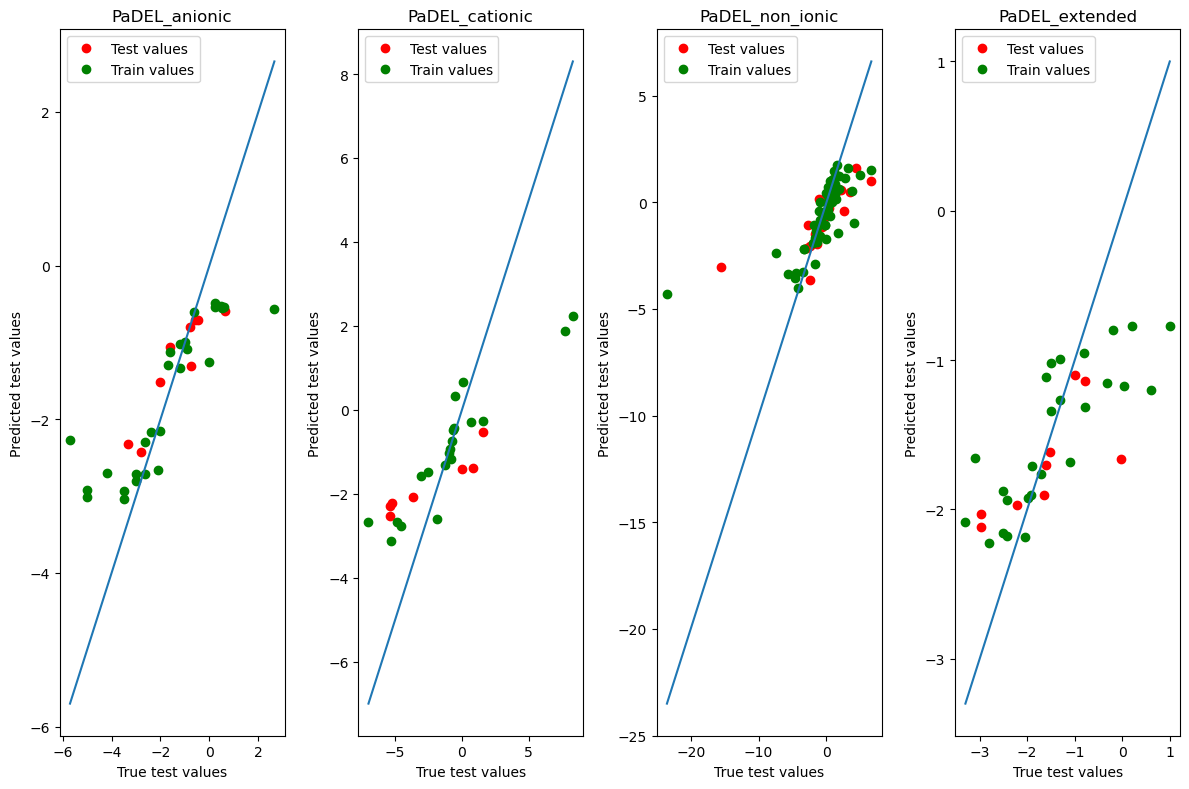

In [13]:
calculate_to_score(RandomForestRegressor(random_state = 0, n_jobs=-1), estimator_name = 'Random Forest', param_grid =  space)
               

**LightGBM**

In [14]:
space = {'lgbmregressor__max_depth':hp.randint('max_depth', 3, 12),
        'lgbmregressor__boosting_type':hp.choice('boosting_type', ['gbdt']),
        'lgbmregressor__reg_alpha':hp.loguniform('reg_alpha', -3*np.log(10), 1*np.log(10)),
         'lgbmregressor__reg_lamdba':hp.loguniform('reg_lambda', -3*np.log(10), 1*np.log(10)),
        'lgbmregressor__learning_rate':hp.loguniform('learning_rate', -3*np.log(10), 1*np.log(10)),
        'lgbmregressor__n_estimators':hp.randint('n_estimators', 50, 300),
        'lgbmregressor__n_leaves':hp.randint('n_leaves', 10, 50),
        'lgbmregressor__min_child_samples': hp.randint('min_child_samples', 5, 30)}

100%|██████████| 30/30 [00:09<00:00,  3.06trial/s, best loss: 1.1925105638830513]
{'boosting_type': 0, 'learning_rate': 0.06117415461055491, 'max_depth': 4, 'min_child_samples': 11, 'n_estimators': 172, 'n_leaves': 10, 'reg_alpha': 4.072293528165599, 'reg_lambda': 0.9660021447774849}
100%|██████████| 30/30 [00:08<00:00,  3.45trial/s, best loss: 2.526146296233932]
{'boosting_type': 0, 'learning_rate': 1.879244691601422, 'max_depth': 4, 'min_child_samples': 12, 'n_estimators': 99, 'n_leaves': 23, 'reg_alpha': 0.011453661891560048, 'reg_lambda': 0.012525731196256735}
100%|██████████| 30/30 [00:19<00:00,  1.54trial/s, best loss: 1.5103526605382978]  
{'boosting_type': 0, 'learning_rate': 0.01566825606785074, 'max_depth': 4, 'min_child_samples': 17, 'n_estimators': 285, 'n_leaves': 23, 'reg_alpha': 1.166432403758257, 'reg_lambda': 0.6717039185588479}
100%|██████████| 30/30 [00:11<00:00,  2.72trial/s, best loss: 0.7298558599824432]
{'boosting_type': 0, 'learning_rate': 0.1808805266554101, 'm

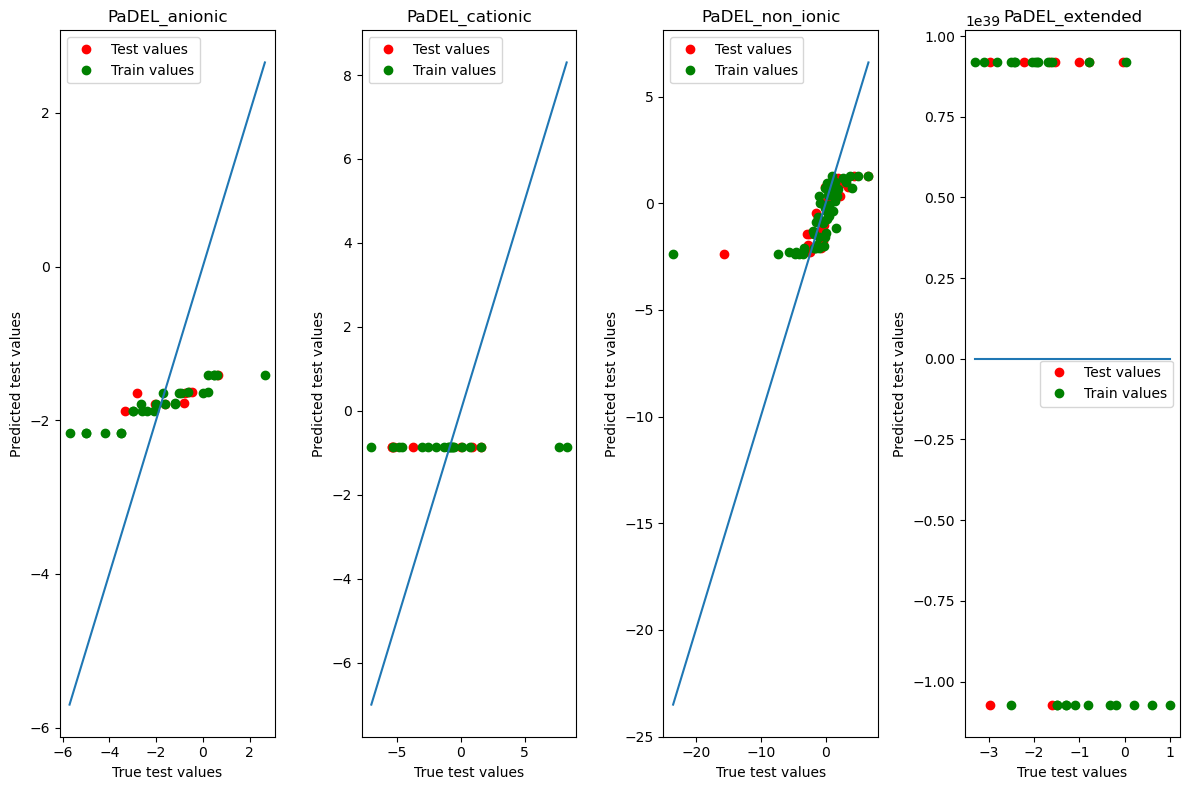

In [15]:
calculate_to_score(LGBMRegressor(verbosity = -1), estimator_name='Gradient boosting', param_grid = space)

**SVM**

In [16]:
space = {'svr__C':hp.loguniform('C', -2*np.log(10), 1*np.log(10)),
         'svr__kernel':hp.choice('kernel', ['rbf','poly','linear', 'sigmoid']),
         'svr__degree':hp.choice('degree', [2,3,4]),
         'svr__gamma':hp.choice('gamma', ['scale', 'auto']),
         'svr__coef0':hp.loguniform('coef0', -1, 1)}


100%|██████████| 30/30 [00:07<00:00,  3.88trial/s, best loss: 0.9139211593213215]
{'C': 7.152758833526424, 'coef0': 2.537414014288427, 'degree': 1, 'gamma': 1, 'kernel': 0}
100%|██████████| 30/30 [00:05<00:00,  5.49trial/s, best loss: 1.8987145284680793]
{'C': 0.17112628961243573, 'coef0': 2.6549895035760436, 'degree': 2, 'gamma': 1, 'kernel': 2}
 97%|█████████▋| 29/30 [00:06<00:00,  4.17trial/s, best loss: 1.4599413762502733]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=15000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=15000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



100%|██████████| 30/30 [00:06<00:00,  4.67trial/s, best loss: 1.4599413762502733]
{'C': 9.752909674294589, 'coef0': 0.3778075024313941, 'degree': 1, 'gamma': 1, 'kernel': 1}
100%|██████████| 30/30 [00:05<00:00,  5.34trial/s, best loss: 0.5394886879662081]
{'C': 0.03816646541480999, 'coef0': 0.670962401453654, 'degree': 2, 'gamma': 0, 'kernel': 2}


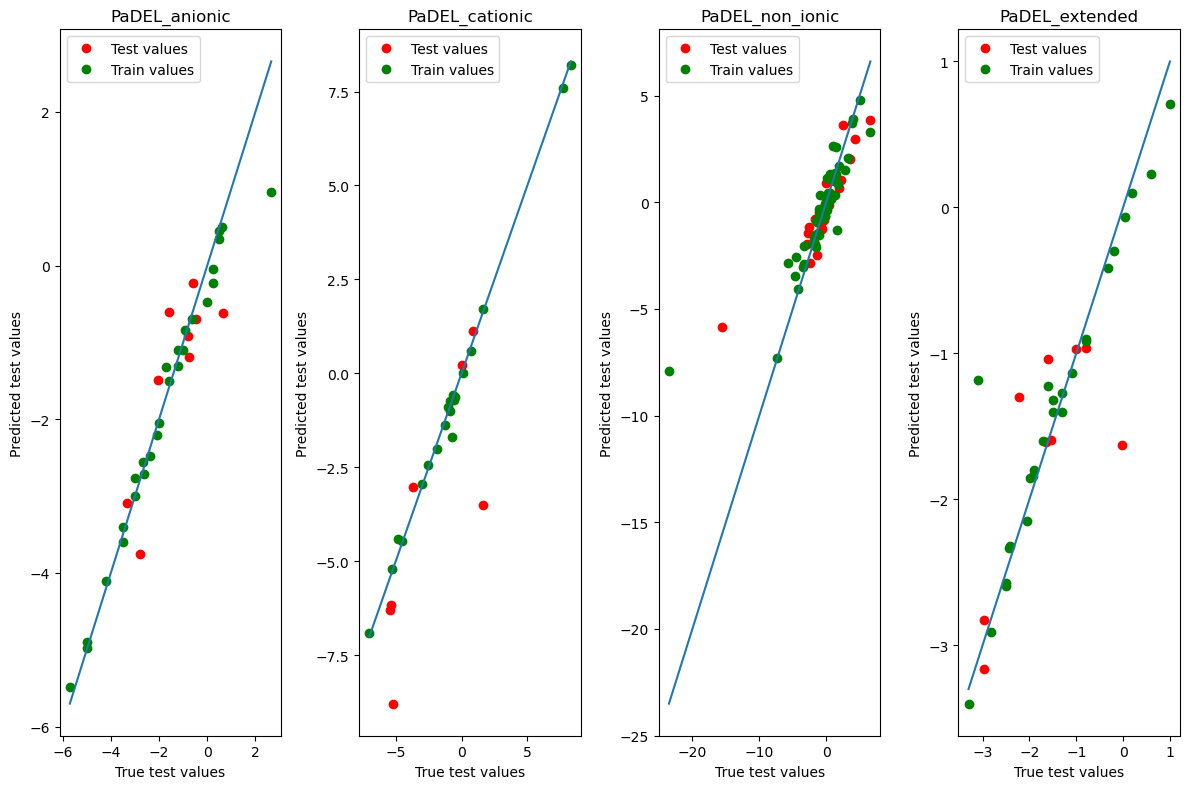

In [17]:
calculate_to_score(SVR(max_iter = 15000), estimator_name = 'SVR', param_grid = space)
                                                                


**KNearestneighbors**

In [18]:
space = {
    'kneighborsregressor__n_neighbors': hp.randint('n_neighbors', 3, 16),  # Увеличил диапазон
    'kneighborsregressor__weights': hp.choice('weights', ['uniform', 'distance']),
    'kneighborsregressor__metric': hp.choice('metric', ['minkowski', 'euclidean', 'manhattan']),  # Упростил выбор
    'kneighborsregressor__p': hp.uniform('p', 1, 3),  # Параметр для minkowski
    'kneighborsregressor__algorithm': hp.choice('algorithm', ['auto', 'ball_tree', 'kd_tree']),
    'kneighborsregressor__leaf_size': hp.randint('leaf_size', 10, 50)  # Для tree-based алгоритмов
}

100%|██████████| 30/30 [00:05<00:00,  5.77trial/s, best loss: 1.042828147450641]
{'algorithm': 1, 'leaf_size': 21, 'metric': 1, 'n_neighbors': 4, 'p': 2.7547987201285498, 'weights': 1}
100%|██████████| 30/30 [00:04<00:00,  6.02trial/s, best loss: 2.294956858880089] 
{'algorithm': 0, 'leaf_size': 33, 'metric': 0, 'n_neighbors': 13, 'p': 2.8684867420387414, 'weights': 1}
100%|██████████| 30/30 [00:05<00:00,  5.15trial/s, best loss: 1.5318109690001698]
{'algorithm': 1, 'leaf_size': 16, 'metric': 2, 'n_neighbors': 12, 'p': 2.3729659398839216, 'weights': 1}
100%|██████████| 30/30 [00:05<00:00,  5.21trial/s, best loss: 0.7282152067205879]
{'algorithm': 2, 'leaf_size': 49, 'metric': 0, 'n_neighbors': 3, 'p': 2.1379319476339744, 'weights': 1}


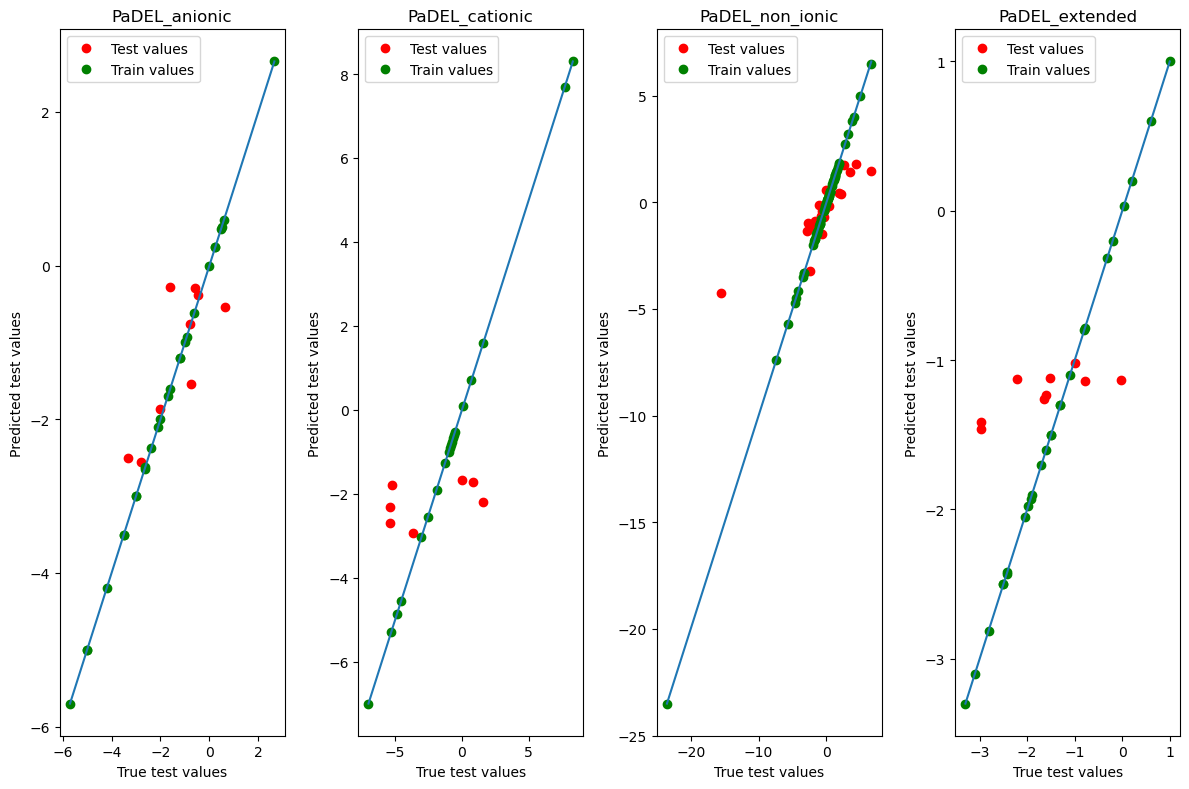

In [19]:
calculate_to_score(KNeighborsRegressor(), estimator_name='KMeans', param_grid=space)

Let's save results into pickle file and show the final scores model in readable format

In [20]:
with open('scores_padel_descs.pickle', 'wb') as output:
    pickle.dump(scores, output)

In [21]:
pd.DataFrame(scores['PaDEL_anionic'])

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,PaDEL,Linear Regression,0.492478,0.929206,1.180136,0.606651,0.737492,0.623527,0.999473,0.044866,0.034412
1,PaDEL,Random Forest,0.275668,1.249655,1.289890,0.710515,0.632677,0.507123,0.608470,1.223260,0.827528
2,PaDEL,Gradient boosting,0.133018,1.192511,1.349183,0.046872,1.148007,1.013949,0.225420,1.720558,1.389464
3,PaDEL,SVR,0.501668,0.913921,1.174757,0.662155,0.683482,0.568474,0.962786,0.377130,0.203119
4,PaDEL,KMeans,0.433586,1.042828,1.212974,0.628418,0.716796,0.551393,1.000000,0.000000,0.000000


In [22]:
pd.DataFrame(scores['PaDEL_cationic'])

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,PaDEL,Linear Regression,0.515645,1.849424,1.588249,0.697374,1.607916,1.003849,0.980612,0.504691,0.365099
1,PaDEL,Random Forest,-0.019760,2.440360,1.913164,0.318027,2.413759,2.332544,0.575348,2.361957,1.534658
2,PaDEL,Gradient boosting,-0.111162,2.526146,1.954664,-0.297533,3.329428,3.039700,0.000000,3.624561,2.368233
3,PaDEL,SVR,0.429475,1.898715,1.654613,0.318862,2.412281,1.644719,0.995201,0.251084,0.159655
4,PaDEL,KMeans,0.072651,2.294957,1.868265,0.117359,2.746013,2.571760,1.000000,0.000000,0.000000


In [23]:
pd.DataFrame(scores['PaDEL_non_ionic'])

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,PaDEL,Linear Regression,0.542886,1.585913,1.604600,0.387180,3.246398,1.808934,0.976205,0.587437,0.366652
1,PaDEL,Random Forest,0.267572,1.425404,1.805311,0.371758,3.286993,1.816844,0.422575,2.893806,1.272731
2,PaDEL,Gradient boosting,0.299650,1.510353,1.785211,0.344015,3.358786,1.874619,0.316065,3.149407,1.523316
3,PaDEL,SVR,0.456918,1.459941,1.675240,0.670266,2.381319,1.356761,0.668568,2.192395,0.817801
4,PaDEL,KMeans,0.204877,1.531811,1.842762,0.494001,2.949919,1.674582,1.000000,0.000000,0.000000


In [24]:
pd.DataFrame(scores['PaDEL_extended'])

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,PaDEL,Linear Regression,0.378005,0.617476,0.937364,1.145169e-01,8.657730e-01,5.996270e-01,8.363953e-01,4.506304e-01,3.379292e-01
1,PaDEL,Random Forest,0.093009,0.757586,1.030059,4.020561e-01,7.114496e-01,5.077462e-01,5.078767e-01,7.815551e-01,5.906531e-01
2,PaDEL,Gradient boosting,0.252345,0.729856,0.981492,-1.076668e+78,9.546734e+38,9.525496e+38,-7.930274e+77,9.921257e+38,9.891861e+38
3,PaDEL,SVR,0.442170,0.539489,0.912193,4.982143e-01,6.517380e-01,4.152939e-01,8.678488e-01,4.050029e-01,1.965468e-01
4,PaDEL,KMeans,0.136104,0.728215,1.017599,-9.770596e-03,9.245390e-01,7.563588e-01,1.000000e+00,0.000000e+00,0.000000e+00
